## Import Lib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

## EDA

In [2]:
# root folder is mc1

nodes = pd.read_csv('../../mc1_nodes.csv')

edges = pd.read_csv('../../mc1_edges.csv')

In [11]:
# nodes
print(nodes.columns)
print(edges.columns)

Index(['Node Type', 'name', 'single', 'release_date', 'genre', 'notable', 'id',
       'written_date', 'stage_name', 'notoriety_date'],
      dtype='object')
Index(['Edge Type', 'source', 'target', 'key'], dtype='object')


In [ ]:
edges[edges['target'] == 620]

,Edge Type,source,target,key,target_is_oceanus_folk
1745,RecordedBy,673,620,0,False
1746,DistributedBy,673,620,1,False
2514,RecordedBy,980,620,0,False
2515,DistributedBy,980,620,1,False
4611,RecordedBy,1742,620,0,False
...,...,...,...,...,...
35177,DistributedBy,16409,620,1,False
35258,RecordedBy,16454,620,0,False
35259,DistributedBy,16454,620,1,False
35548,RecordedBy,16612,620,0,False


In [12]:
nodes.head()

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
0,Song,Breaking These Chains,True,2017.0,Oceanus Folk,True,0,NaN,NaN,NaN
1,Person,Carlos Duffy,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
2,Person,Min Qin,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
3,Person,Xiuying Xie,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
4,RecordLabel,Nautical Mile Records,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN


In [36]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17412 entries, 0 to 17411
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Node Type       17412 non-null  object 
 1   name            17412 non-null  object 
 2   single          3615 non-null   object 
 3   release_date    4611 non-null   float64
 4   genre           4611 non-null   object 
 5   notable         4611 non-null   object 
 6   id              17412 non-null  int64  
 7   written_date    1455 non-null   float64
 8   stage_name      523 non-null    object 
 9   notoriety_date  649 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 1.3+ MB


In [37]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37857 entries, 0 to 37856
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Edge Type               37857 non-null  object
 1   source                  37857 non-null  int64 
 2   target                  37857 non-null  int64 
 3   key                     37857 non-null  int64 
 4   target_is_oceanus_folk  37857 non-null  bool  
dtypes: bool(1), int64(3), object(1)
memory usage: 1.2+ MB


In [13]:
edges.head()

,Edge Type,source,target,key
0,InterpolatesFrom,0,1841,0
1,RecordedBy,0,4,0
2,PerformerOf,1,0,0
3,ComposerOf,1,16180,0
4,PerformerOf,2,0,0


In [ ]:
## Filter only Oceanus Folk genre --> album and songs only
oceanus_folk_nodes = nodes[nodes['genre'] == 'Oceanus Folk']
## Get the IDs of the Oceanus Folk artists
# set is store unique values
oceanus_folk_ids = set(oceanus_folk_nodes['id'])

In [15]:
oceanus_folk_nodes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305 entries, 0 to 17411
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Node Type       305 non-null    object 
 1   name            305 non-null    object 
 2   single          235 non-null    object 
 3   release_date    305 non-null    float64
 4   genre           305 non-null    object 
 5   notable         305 non-null    object 
 6   id              305 non-null    int64  
 7   written_date    91 non-null     float64
 8   stage_name      0 non-null      object 
 9   notoriety_date  38 non-null     float64
dtypes: float64(3), int64(1), object(6)
memory usage: 26.2+ KB


In [16]:
# how did influence spread over time
# if target is oceanus folk related, it means that someone is influenced by oceanus folk
edges['target_is_oceanus_folk'] = edges['target'].isin(oceanus_folk_ids)

# number of artists influenced by oceanus folk over time
spread_over_time = edges[edges['target_is_oceanus_folk']].merge(nodes[['id', 'release_date']], left_on='target', right_on='id', how='left').groupby('release_date').size()

In [17]:
edges[edges['target_is_oceanus_folk'] == True]

,Edge Type,source,target,key,target_is_oceanus_folk
2,PerformerOf,1,0,0,True
3,ComposerOf,1,16180,0,True
4,PerformerOf,2,0,0,True
5,ProducerOf,2,16180,0,True
6,PerformerOf,3,0,0,True
...,...,...,...,...,...
37742,RecordedBy,17370,17329,0,True
37743,RecordedBy,17370,17330,0,True
37744,RecordedBy,17370,17331,0,True
37835,LyricistOf,17396,17245,0,True


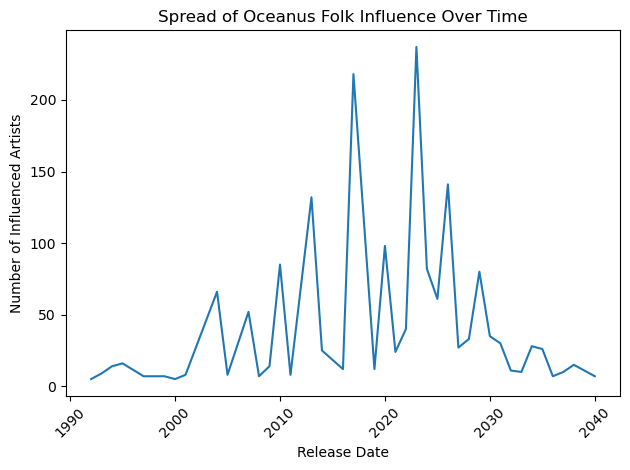

In [19]:
spread_over_time.plot(kind='line')
plt.title('Spread of Oceanus Folk Influence Over Time')
plt.xlabel('Release Date')
plt.ylabel('Number of Influenced Artists')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

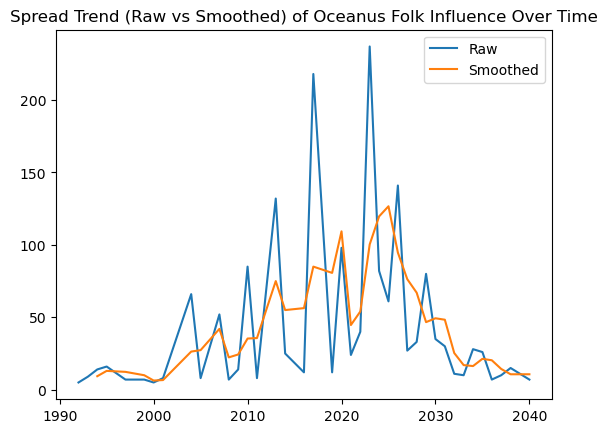

In [20]:
plt.figure()
plt.plot(spread_over_time.index, spread_over_time.values, label='Raw')
# smoothed trend reduce noise by averaging over a window (e.g., rolling mean)
plt.plot(spread_over_time.index, spread_over_time.rolling(3).mean(), label='Smoothed')
plt.legend()
plt.title("Spread Trend (Raw vs Smoothed) of Oceanus Folk Influence Over Time")
plt.show()

In [21]:
# rank spread over time by descending order
spread_over_time.sort_values(ascending=False).head(10)

release_date
2023.0    237
2017.0    218
2026.0    141
2013.0    132
2020.0     98
2010.0     85
2024.0     82
2029.0     80
2004.0     66
2025.0     61
dtype: int64

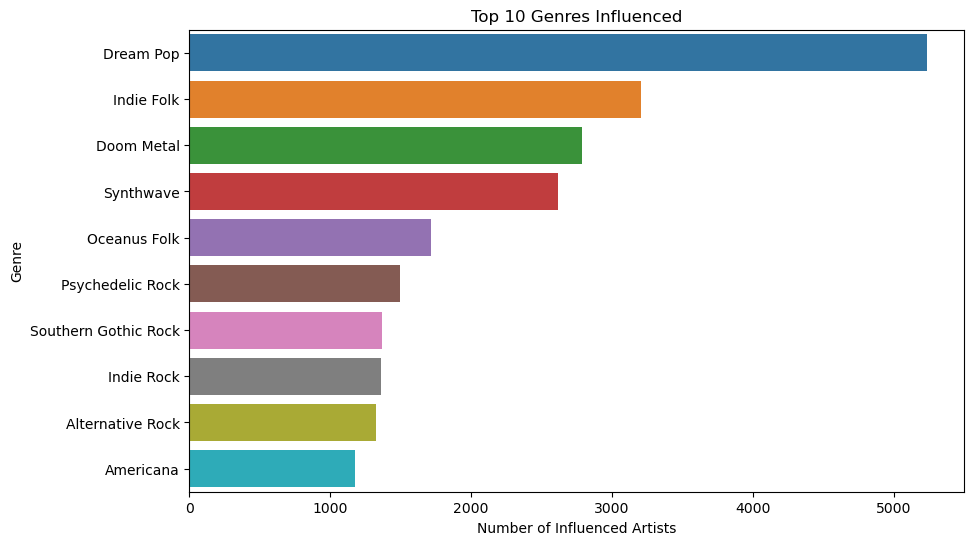

In [22]:
# genres influenced
influenced = edges.merge(nodes[['id', 'genre']], left_on='target', right_on='id', how='left')
influenced_genres = influenced['genre'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=influenced_genres.values, y=influenced_genres.index)
plt.title('Top 10 Genres Influenced')
plt.xlabel('Number of Influenced Artists')
plt.ylabel('Genre')
plt.show()

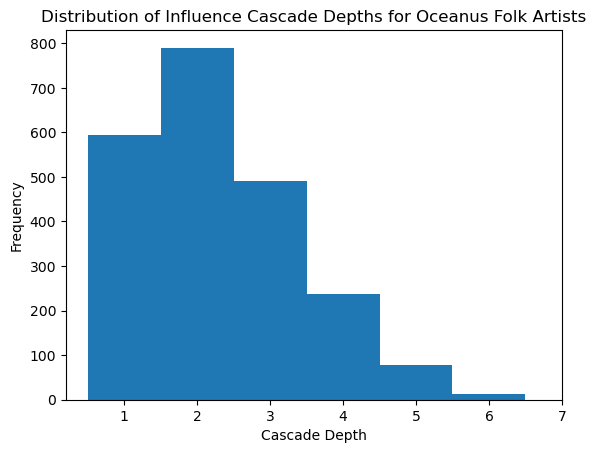

In [34]:
# cascades deapth of spread (how far influence spreads)
lengths = []

# build influence graph
G = nx.from_pandas_edgelist(
    edges,
    source='source',
    target='target',
    create_using=nx.DiGraph()
)

for node in oceanus_folk_ids:
    for target in nx.descendants(G, node):
        try:
            length = nx.shortest_path_length(G, source=node, target=target)
            lengths.append(length)
        except nx.NetworkXNoPath:
            continue

plt.hist(lengths, bins=range(1, max(lengths) + 1), align='left')
plt.title('Distribution of Influence Cascade Depths for Oceanus Folk Artists')
plt.xlabel('Cascade Depth')
plt.ylabel('Frequency')
plt.xticks(range(1, max(lengths) + 1))
plt.show()

In [25]:
edges

,Edge Type,source,target,key,target_is_oceanus_folk
0,InterpolatesFrom,0,1841,0,False
1,RecordedBy,0,4,0,False
2,PerformerOf,1,0,0,True
3,ComposerOf,1,16180,0,True
4,PerformerOf,2,0,0,True
...,...,...,...,...,...
37852,ComposerOf,17408,17111,0,False
37853,ComposerOf,17408,17112,0,False
37854,ComposerOf,17408,17113,0,False
37855,PerformerOf,17409,17411,0,True


In [26]:
edges['Edge Type'].value_counts()

Edge Type
PerformerOf           13587
RecordedBy             3798
ComposerOf             3290
ProducerOf             3209
DistributedBy          3013
LyricistOf             2985
InStyleOf              2289
InterpolatesFrom       1574
LyricalReferenceTo     1496
CoverOf                1429
DirectlySamples         619
MemberOf                568
Name: count, dtype: int64

## Influences of Oceanus Folk

In [150]:
# influence edges
influence_list = ['InStyleOf', 'InterpolatesFrom', 'CoverOf', 'LyricalReferenceTo', 'DirectlySamples']

# filter edges to only include influence edges + target is oceanus folk
influence_edges = edges[(edges['Edge Type'].isin(influence_list)) & (edges['target_is_oceanus_folk'] == True)]
influence_edges.head()

,Edge Type,source,target,key,target_is_oceanus_folk
554,InStyleOf,196,13324,0,True
1510,DirectlySamples,577,3711,0,True
1512,DirectlySamples,577,3025,0,True
1513,CoverOf,577,14720,0,True
1731,LyricalReferenceTo,662,16524,0,True


In [ ]:
# songs that were influenced by oceanus folk (source)
songs_influenced_by_oceanus_folk = influence_edges[['source']]

songs_influenced_by_oceanus_folk.rename(columns={'source': 'Song Performed'}, inplace=True)

# artists / musical groups and their songs released (edge type: performerof, composerof, producerof, lyricistof)
artists_songs_info = edges[edges['Edge Type'].isin(['PerformerOf', 'ComposerOf', 'ProducerOf', 'LyricistOf'])]
artists_songs_info.head()


/var/folders/b0/7h5dypn547v1m41jlq7_n24m0000gn/T/ipykernel_56882/2575616308.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  songs_influenced_by_oceanus_folk.rename(columns={'source': 'Song Performed'}, inplace=True)


,Edge Type,source,target,key,target_is_oceanus_folk
2,PerformerOf,1,0,0,True
3,ComposerOf,1,16180,0,True
4,PerformerOf,2,0,0,True
5,ProducerOf,2,16180,0,True
6,PerformerOf,3,0,0,True


In [ ]:
# merge both songs with artists influenced by oceanus folk (left join on Song Performed with target)
# only if target_is_oceanus_folk is True for songs influenced by oceanus folk
artists_influenced_by_oceanus_folk = songs_influenced_by_oceanus_folk.merge(artists_songs_info, left_on='Song Performed', right_on='target', how='left')

artists_influenced_by_oceanus_folk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Song Performed  2215 non-null   int64
 1   target          2215 non-null   int64
dtypes: int64(2)
memory usage: 34.7 KB


In [186]:
artists_influenced_by_oceanus_folk

,Song Performed,target
0,196,196
1,196,196
2,196,196
3,577,577
4,577,577
...,...,...
2210,17156,17156
2211,17156,17156
2212,17352,17352
2213,17354,17354


In [177]:
artists_influenced_by_oceanus_folk.head()

agg_artists_appearance = artists_influenced_by_oceanus_folk.groupby('source').size().reset_index(name='Appearance Count')
agg_artists_appearance.sort_values(by='Appearance Count', ascending=False).head(10)

,source,Appearance Count
301,5038,20
279,4395,15
585,9447,12
961,16802,12
265,4298,12
686,11338,12
278,4394,12
53,1180,11
214,3504,10
270,4304,10


In [178]:
artists_info_influenced = agg_artists_appearance.merge(nodes, left_on='source', right_on='id', how='left')
artists_info_influenced.sort_values(by='Appearance Count', ascending=False, inplace=True)
artists_info_influenced

,source,Appearance Count,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
301,5038,20,Person,Min He,NaN,NaN,NaN,NaN,5038,NaN,NaN,NaN
279,4395,15,Person,Xia Cui,NaN,NaN,NaN,NaN,4395,NaN,NaN,NaN
585,9447,12,Person,Jie Fang,NaN,NaN,NaN,NaN,9447,NaN,NaN,NaN
961,16802,12,MusicalGroup,Cosmic Drift,NaN,NaN,NaN,NaN,16802,NaN,NaN,NaN
265,4298,12,Person,Qiang Yuan,NaN,NaN,NaN,NaN,4298,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
496,8123,1,Person,Guiying Dong,NaN,NaN,NaN,NaN,8123,NaN,NaN,NaN
498,8125,1,Person,Chao Yi,NaN,NaN,NaN,NaN,8125,NaN,NaN,NaN
499,8126,1,Person,Li Huang,NaN,NaN,NaN,NaN,8126,NaN,NaN,NaN
500,8127,1,Person,Ming Yin,NaN,NaN,NaN,NaN,8127,NaN,NaN,NaN


In [165]:
test = edges[edges['source'] == 17408]
# list_target = test['target'].tolist()
test
# # list target if match with nodes id
# list_target_nodes = nodes[nodes['id'].isin(list_target)]
# list_target_nodes

,Edge Type,source,target,key,target_is_oceanus_folk
37852,ComposerOf,17408,17111,0,False
37853,ComposerOf,17408,17112,0,False
37854,ComposerOf,17408,17113,0,False


In [170]:
edges[edges['source'] == 10309]

,Edge Type,source,target,key,target_is_oceanus_folk
23555,CoverOf,10309,4069,0,False
23556,CoverOf,10309,16162,0,False
23557,CoverOf,10309,8055,0,False
23558,DistributedBy,10309,635,0,False


In [174]:
nodes[nodes['id'] == 635]

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
635,RecordLabel,Echoes of Seoul,NaN,NaN,NaN,NaN,635,NaN,NaN,NaN


In [136]:
list_influence = edges[edges['target'].isin(list_target)]
list_influence

,Edge Type,source,target,key,target_is_oceanus_folk
1704,PerformerOf,648,11465,0,False
12541,CoverOf,5021,7736,0,False
12606,LyricistOf,5036,5035,0,False
12607,ComposerOf,5037,5035,0,False
12608,PerformerOf,5038,5035,0,False
12609,ProducerOf,5038,5035,1,False
12610,PerformerOf,5038,7133,0,False
12611,ComposerOf,5038,7736,0,False
12612,PerformerOf,5038,8118,0,False
12613,ProducerOf,5038,8118,1,False


In [109]:
influenced_artists_info['Node Type'].value_counts()

Node Type
Song     300
Album     77
Name: count, dtype: int64

In [46]:
influenced_artists_info

,source,target,Edge Type,Node Type,name,single,release_date,genre,notable,written_date,stage_name,notoriety_date
0,196,13324,InStyleOf,Song,Radiant Dreams,True,2017.0,Indie Folk,True,NaN,NaN,NaN
1,577,3711,DirectlySamples,Album,Roadmap to Your Heart,NaN,2027.0,Space Rock,True,2027.0,NaN,NaN
2,577,3025,DirectlySamples,Album,Roadmap to Your Heart,NaN,2027.0,Space Rock,True,2027.0,NaN,NaN
3,577,14720,CoverOf,Album,Roadmap to Your Heart,NaN,2027.0,Space Rock,True,2027.0,NaN,NaN
4,662,16524,LyricalReferenceTo,Album,Waiting for Steven,NaN,2028.0,Indie Folk,True,2021.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
372,17153,11767,InStyleOf,Song,The Final Broadcast,True,2034.0,Indie Rock,True,NaN,NaN,NaN
373,17156,7687,InStyleOf,Album,City Lights & Cigarette Dreams,NaN,2031.0,Synthpop,True,2030.0,NaN,NaN
374,17352,11485,InStyleOf,Song,Whispers on the Jetty Wind,True,2031.0,Oceanus Folk,True,NaN,NaN,2031.0
375,17354,7180,CoverOf,Song,Seven Fathoms Deep,False,2031.0,Oceanus Folk,True,NaN,NaN,2031.0


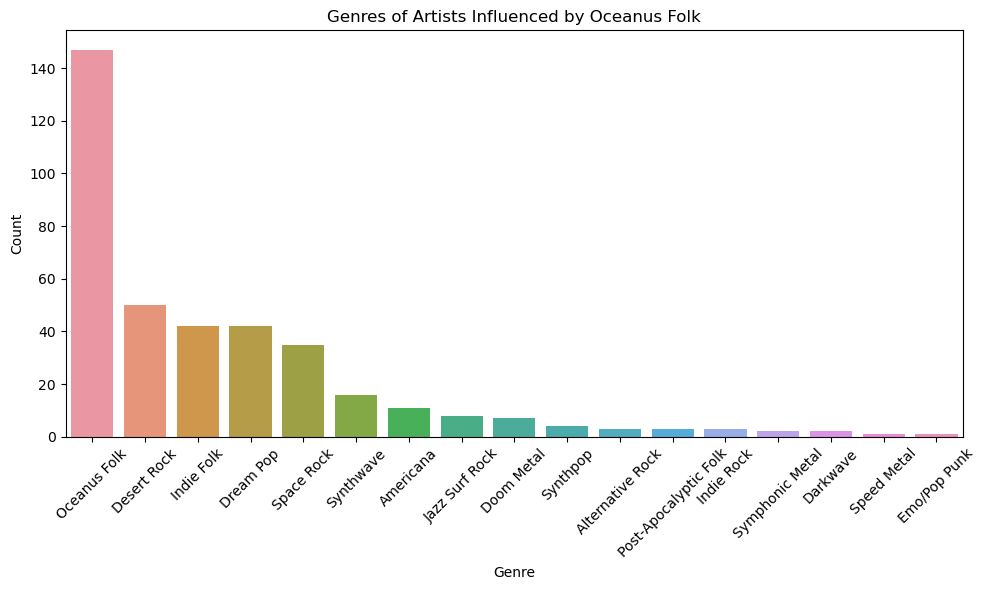

In [47]:
# charts of influenced_artists_info dataframe
plt.figure(figsize=(10, 6))
sns.countplot(data=influenced_artists_info, x='genre', order=influenced_artists_info['genre'].value_counts().index)
plt.title('Genres of Artists Influenced by Oceanus Folk')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

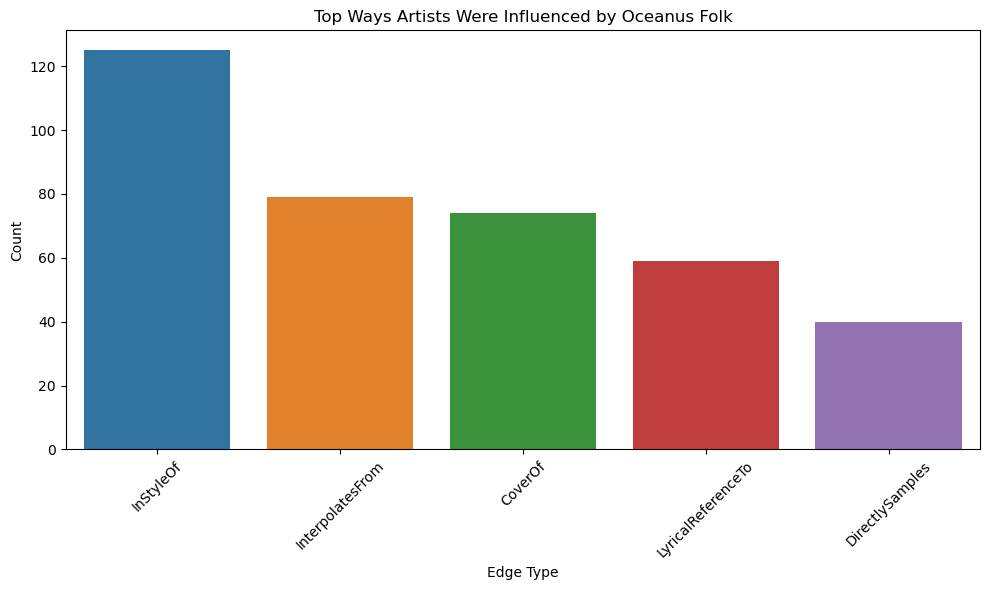

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(data=influenced_artists_info, x='Edge Type', order=influenced_artists_info['Edge Type'].value_counts().index)
plt.title('Top Ways Artists Were Influenced by Oceanus Folk')
plt.xlabel('Edge Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

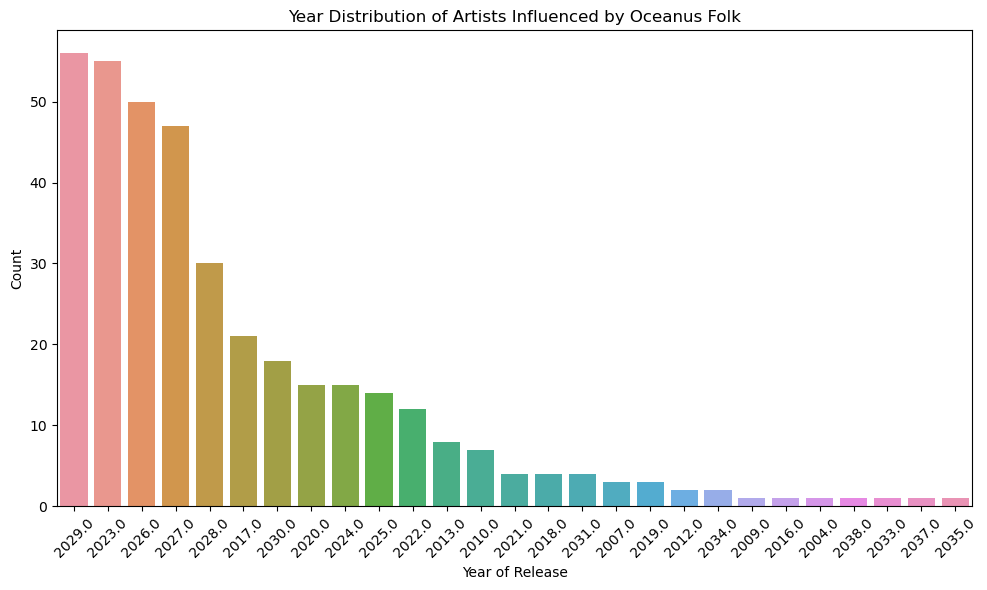

In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(data=influenced_artists_info, x='release_date', order=influenced_artists_info['release_date'].value_counts().index)
plt.title('Year Distribution of Artists Influenced by Oceanus Folk')
plt.xlabel('Year of Release')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Sailor Shift / Band ID

In [59]:
nodes[(nodes['name'] == 'Sailor Shift') | (nodes['name'] == 'Ivy Echos')]

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
17255,Person,Sailor Shift,NaN,NaN,NaN,NaN,17255,NaN,NaN,NaN
17260,MusicalGroup,Ivy Echos,NaN,NaN,NaN,NaN,17260,NaN,NaN,NaN


In [65]:
# information of Sailor Shift and Ivy Echos profile
sailor_shift_profile = edges[(edges['source'] == 17255) | (edges['source'] == 17260)]
sailor_shift_profile

,Edge Type,source,target,key,target_is_oceanus_folk
37408,LyricistOf,17255,16961,0,False
37409,LyricistOf,17255,16989,0,True
37410,LyricistOf,17255,16999,0,False
37411,LyricistOf,17255,17047,0,True
37412,LyricistOf,17255,17048,0,True
...,...,...,...,...,...
37490,PerformerOf,17260,17271,0,True
37491,InStyleOf,17260,17167,0,False
37492,InStyleOf,17260,17314,0,False
37493,LyricalReferenceTo,17260,17299,0,False


In [66]:
# destination nodes of Sailor Shift and Ivy Echos [Target nodes]
merge_sailor_ivy = sailor_shift_profile.merge(nodes, left_on='target', right_on='id', how='left')
merge_sailor_ivy.drop(columns=['id', 'target_is_oceanus_folk'], inplace=True)

# replace source value with name (17255 = Sailor Shift, 17260 = Ivy Echos)
merge_sailor_ivy['source'] = merge_sailor_ivy['source'].replace({17255: 'Sailor Shift', 17260: 'Ivy Echos'})
merge_sailor_ivy

,Edge Type,source,target,key,Node Type,name,single,release_date,genre,notable,written_date,stage_name,notoriety_date
0,LyricistOf,Sailor Shift,16961,0,Album,Neon Heartbeat,NaN,2031.0,Synthwave,False,2030.0,NaN,NaN
1,LyricistOf,Sailor Shift,16989,0,Album,Ballads for the End of Time,NaN,2033.0,Oceanus Folk,True,2032.0,NaN,NaN
2,LyricistOf,Sailor Shift,16999,0,Album,Melancholy Circuitry,NaN,2033.0,Americana,True,2032.0,NaN,NaN
3,LyricistOf,Sailor Shift,17047,0,Album,Drifting Between the Stars and the Sea,NaN,2034.0,Oceanus Folk,True,2033.0,NaN,NaN
4,LyricistOf,Sailor Shift,17048,0,Album,Artificial Sunsets,NaN,2035.0,Oceanus Folk,True,2034.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,PerformerOf,Ivy Echos,17271,0,Song,Tidepool Epigrams,False,2026.0,Oceanus Folk,False,NaN,NaN,NaN
63,InStyleOf,Ivy Echos,17167,0,MusicalGroup,The Salty Wakes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,InStyleOf,Ivy Echos,17314,0,MusicalGroup,The Tide Singer's Knot,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,LyricalReferenceTo,Ivy Echos,17299,0,MusicalGroup,The Saltwater Weavers,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Artists Most influencial

In [3]:
#  filter the Edge Type by influence edges (InStyleOf, InterpolatesFrom, CoverOf, LyricalReferenceTo, DirectlySamples)
influence_list = ['InStyleOf', 'InterpolatesFrom', 'CoverOf', 'LyricalReferenceTo', 'DirectlySamples']
influence_edges = edges[edges['Edge Type'].isin(influence_list)]
print(f"Number of influence edges: {influence_edges.shape[0]}")

Number of influence edges: 7407


In [23]:
# source is influenced by target

# dictionary of Target ID from influence edges, and value of how many times it appears in influence edges
list_target = influence_edges['target'].tolist()

# filter Nodes dataframe to only include rows where id is in list_target
influenced_artists_info = nodes[nodes['id'].isin(list_target)]
influenced_artists_info.head()

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
26,Song,"Clean Lungs, Clear Mind",False,2022.0,Speed Metal,True,26,NaN,NaN,NaN
39,Song,Healthier Than Yesterday,True,2010.0,Indie Folk,True,39,NaN,NaN,NaN
42,Song,Midnight Clarity,True,2020.0,Synthwave,True,42,NaN,NaN,NaN
48,Song,Arcane Whispers,False,2017.0,Indie Folk,True,48,NaN,NaN,NaN
60,Song,Runes and Riddles,True,2023.0,Americana,True,60,NaN,NaN,NaN


In [45]:
influenced_artists_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2379 entries, 26 to 17327
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Node Type       2379 non-null   object 
 1   name            2379 non-null   object 
 2   single          1856 non-null   object 
 3   release_date    2371 non-null   float64
 4   genre           2371 non-null   object 
 5   notable         2371 non-null   object 
 6   id              2379 non-null   int64  
 7   written_date    753 non-null    float64
 8   stage_name      0 non-null      object 
 9   notoriety_date  359 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 204.4+ KB


In [24]:
# OF genre influenced artists
OF_influential_artists = nodes[nodes['genre'] == 'Oceanus Folk']

OF_influential_artists.head()

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
0,Song,Breaking These Chains,True,2017.0,Oceanus Folk,True,0,NaN,NaN,NaN
553,Song,Midnight's Restless Echo,True,2013.0,Oceanus Folk,True,553,NaN,NaN,NaN
720,Song,Ethereal Wanderer,True,2023.0,Oceanus Folk,True,720,NaN,NaN,2023.0
746,Song,"Let Me Go, Let Me Rise",True,2027.0,Oceanus Folk,True,746,NaN,NaN,NaN
757,Song,Mirage of Memories,True,2023.0,Oceanus Folk,True,757,NaN,NaN,NaN


In [46]:
OF_influential_artists.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305 entries, 0 to 17411
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Node Type       305 non-null    object 
 1   name            305 non-null    object 
 2   single          235 non-null    object 
 3   release_date    305 non-null    float64
 4   genre           305 non-null    object 
 5   notable         305 non-null    object 
 6   id              305 non-null    int64  
 7   written_date    91 non-null     float64
 8   stage_name      0 non-null      object 
 9   notoriety_date  38 non-null     float64
dtypes: float64(3), int64(1), object(6)
memory usage: 26.2+ KB


In [25]:
# from edges, filter if target == OF influential artists ids
OF_influence_edges = edges[edges['target'].isin(OF_influential_artists['id'])]

print(f"Number of influence edges targeting Oceanus Folk artists: {OF_influence_edges.shape[0]}")


Number of influence edges targeting Oceanus Folk artists: 1712


In [138]:
OF_influence_edges['Edge Type'].value_counts()

Edge Type
PerformerOf    748
ComposerOf     206
LyricistOf     199
ProducerOf     142
Name: count, dtype: int64

In [38]:
OF_influence_edges['Edge Type'].value_counts()

Edge Type
PerformerOf           748
ComposerOf            206
LyricistOf            199
ProducerOf            142
InStyleOf             125
InterpolatesFrom       79
CoverOf                74
LyricalReferenceTo     59
DirectlySamples        40
RecordedBy             40
Name: count, dtype: int64

In [39]:
# filter to Artists
artists = ['PerformerOf', 'ComposerOf', 'ProducerOf', 'LyricistOf']

# filter OF_influence_edges to only include artists edges
OF_influence_edges = OF_influence_edges[OF_influence_edges['Edge Type'].isin(artists)]
OF_influence_edges['Edge Type'].value_counts()

Edge Type
PerformerOf    748
ComposerOf     206
LyricistOf     199
ProducerOf     142
Name: count, dtype: int64

In [52]:
edges[edges['Edge Type'].isin(artists)]

,Edge Type,source,target,key
2,PerformerOf,1,0,0
3,ComposerOf,1,16180,0
4,PerformerOf,2,0,0
5,ProducerOf,2,16180,0
6,PerformerOf,3,0,0
...,...,...,...,...
37851,LyricistOf,17407,17113,0
37852,ComposerOf,17408,17111,0
37853,ComposerOf,17408,17112,0
37854,ComposerOf,17408,17113,0


In [42]:
OF_influence_edges

,Edge Type,source,target,key
2,PerformerOf,1,0,0
3,ComposerOf,1,16180,0
4,PerformerOf,2,0,0
5,ProducerOf,2,16180,0
6,PerformerOf,3,0,0
...,...,...,...,...
37677,PerformerOf,17361,17366,0
37678,PerformerOf,17361,17367,0
37679,PerformerOf,17361,17368,0
37835,LyricistOf,17396,17245,0


In [40]:
# get the id of source of OF_influence_edges
artist_of_OF = OF_influence_edges['source'].unique()

# filter nodes to only include artists of OF
artist_of_OF_info = nodes[nodes['id'].isin(artist_of_OF)]
artist_of_OF_info

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
1,Person,Carlos Duffy,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
2,Person,Min Qin,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
3,Person,Xiuying Xie,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN
267,Person,Walter White,NaN,NaN,NaN,NaN,267,NaN,NaN,NaN
274,Person,Li Xie,NaN,NaN,NaN,NaN,274,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
17349,Person,Beatrice Albright,NaN,NaN,NaN,NaN,17349,NaN,Bea Azure,NaN
17355,Person,Daniel O'Connell,NaN,NaN,NaN,NaN,17355,NaN,Kael Storm,NaN
17361,MusicalGroup,Copper Canyon Ghosts,NaN,NaN,NaN,NaN,17361,NaN,NaN,NaN
17396,Person,Bronze Tiger,NaN,NaN,NaN,NaN,17396,NaN,NaN,NaN


In [41]:
artist_of_OF_info['Node Type'].value_counts()

Node Type
Person          732
MusicalGroup     32
Name: count, dtype: int64

In [43]:
# count number of times each artist appears in source of OF_influence_edges
artist_appearance_count = OF_influence_edges['source'].value_counts().reset_index()
artist_appearance_count.columns = ['id', 'Appearance Count']
artist_appearance_count.sort_values(by='Appearance Count', ascending=False, inplace=True)
artist_appearance_count

,id,Appearance Count
0,17255,45
1,17327,12
2,17260,11
3,17349,11
4,17355,11
...,...,...
436,15031,1
435,15033,1
434,15273,1
433,14656,1


In [132]:
nodes[nodes['id'] == 11578]

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
11578,Song,Whispers in the Unknown,True,2026.0,Oceanus Folk,True,11578,2026.0,NaN,NaN


In [137]:
edges[edges['source'] == 17255]

,Edge Type,source,target,key
37408,LyricistOf,17255,16961,0
37409,LyricistOf,17255,16989,0
37410,LyricistOf,17255,16999,0
37411,LyricistOf,17255,17047,0
37412,LyricistOf,17255,17048,0
37413,LyricistOf,17255,17049,0
37414,LyricistOf,17255,17121,0
37415,LyricistOf,17255,17231,0
37416,LyricistOf,17255,17252,0
37417,MemberOf,17255,17260,0


In [142]:
nodes[nodes['genre'] == 'Oceanus Folk']

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
0,Song,Breaking These Chains,True,2017.0,Oceanus Folk,True,0,NaN,NaN,NaN
553,Song,Midnight's Restless Echo,True,2013.0,Oceanus Folk,True,553,NaN,NaN,NaN
720,Song,Ethereal Wanderer,True,2023.0,Oceanus Folk,True,720,NaN,NaN,2023.0
746,Song,"Let Me Go, Let Me Rise",True,2027.0,Oceanus Folk,True,746,NaN,NaN,NaN
757,Song,Mirage of Memories,True,2023.0,Oceanus Folk,True,757,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
17366,Song,"Canyon Echoes, Ocean Dreams",True,2034.0,Oceanus Folk,True,17366,NaN,NaN,2034.0
17367,Song,The Cartographer's Curse,False,2035.0,Oceanus Folk,True,17367,NaN,NaN,2035.0
17368,Song,Shadows in Smuggler's Cove,False,2035.0,Oceanus Folk,True,17368,NaN,NaN,2035.0
17410,Song,Seashell Serenade,True,2030.0,Oceanus Folk,True,17410,NaN,NaN,2030.0


In [155]:
of_by_year = (nodes[nodes['genre'] == 'Oceanus Folk']
              .groupby('release_date')
              .size()
              .reset_index(name='count'))
print(of_by_year.to_string())

    release_date  count
0         1992.0      1
1         1993.0      3
2         1994.0      3
3         1995.0      5
4         1997.0      2
5         1999.0      2
6         2000.0      1
7         2001.0      3
8         2004.0      7
9         2005.0      3
10        2007.0      3
11        2008.0      2
12        2009.0      2
13        2010.0     12
14        2011.0      1
15        2013.0     19
16        2014.0      2
17        2016.0      2
18        2017.0     21
19        2019.0      1
20        2020.0     19
21        2021.0      3
22        2022.0      5
23        2023.0     34
24        2024.0     13
25        2025.0     11
26        2026.0     25
27        2027.0      6
28        2028.0     11
29        2029.0     19
30        2030.0      9
31        2031.0     14
32        2032.0      4
33        2033.0      3
34        2034.0     11
35        2035.0      8
36        2036.0      3
37        2037.0      5
38        2038.0      4
39        2040.0      3


In [185]:
# Step 1: Filter to influence edges AND REMOVE RAW DUPLICATES
# This handles cases where the JSON has the same edge twice
influence_df = edges[edges['Edge Type'].isin(influence_edges)].drop_duplicates()

# Step 2: Identify OF songs
of_songs = nodes[nodes['genre'] == 'Oceanus Folk'][['id']].rename(columns={'id': 'target'})

# Step 3: Keep only edges where TARGET is an OF song
of_targeted = influence_df.merge(of_songs, on='target', how='inner')

# Step 4: Get the SOURCE songs
source_songs = nodes[['id', 'name']].rename(columns={
    'id': 'source',
    'name': 'source_name'
    })
of_targeted = of_targeted.merge(source_songs, on='source', how='left').drop_duplicates()

# Step 5: Get artist roles AND REMOVE RAW DUPLICATES
artists_roles = ['PerformerOf', 'ComposerOf', 'ProducerOf', 'LyricistOf']

performer_edges = edges[edges['Edge Type'].isin(artists_roles)][['source', 'target', 'Edge Type']].rename(columns={
    'source': 'artist_id',
    'target': 'source',
    'Edge Type': 'artist_role'
}).drop_duplicates() # <--- Crucial to prevent multi-role explosion

# Step 6: Final Merge
of_targeted_with_artist = of_targeted.merge(performer_edges, on='source', how='left')

# Get artist names
artist_nodes = nodes[['id', 'name']].rename(columns={'id': 'artist_id', 'name': 'artist_name'})
of_targeted_with_artist = of_targeted_with_artist.merge(artist_nodes, on='artist_id', how='left').drop_duplicates()


# Step 7: Count how many times each artist referenced OF
top_artists = (
    of_targeted_with_artist
    .groupby(['artist_id', 'artist_name'])
    .size()
    .reset_index(name='reference_count')
    .sort_values('reference_count', ascending=False)
    .head(20)
)

print("Top 20 artists most influenced by Oceanus Folk:")
print(top_artists.to_string(index=False))

Top 20 artists most influenced by Oceanus Folk:
 artist_id      artist_name  reference_count
      5038           Min He               20
      4395          Xia Cui               15
      9447         Jie Fang               12
     16802     Cosmic Drift               12
      4298       Qiang Yuan               12
     11338        Ming Xiao               12
      4394       Xiuying Li               12
      1180     Guiying Liao               11
      3504 Zacharie Martins               10
      4304          Jun Liu               10
      5037     Xiuying Qian               10
      5036       Qiang Qian               10
      4397         Lei Shen                9
      1493          Lei Jin                8
     13235    Summer Bender                8
      5902         Juan Liu                8
     16753  Crimson Theorem                8
      1492          Juan Yu                8
     10637       Ming Zhong                8
      1491         Yong Lai                7


In [222]:
# Final Check for Min He
min_he_references = of_targeted_with_artist[(of_targeted_with_artist['artist_name'] == 'Min He')]
print(min_he_references.to_string(index=False))


         Edge Type  source  target  key                            source_name  artist_id artist_role artist_name
LyricalReferenceTo    5035    3828    0 Skogens Fortelling (The Forest's Tale)       5038 PerformerOf      Min He
LyricalReferenceTo    5035    3828    0 Skogens Fortelling (The Forest's Tale)       5038  ProducerOf      Min He
LyricalReferenceTo    5035   12138    0 Skogens Fortelling (The Forest's Tale)       5038 PerformerOf      Min He
LyricalReferenceTo    5035   12138    0 Skogens Fortelling (The Forest's Tale)       5038  ProducerOf      Min He
         InStyleOf    5035   10159    0 Skogens Fortelling (The Forest's Tale)       5038 PerformerOf      Min He
         InStyleOf    5035   10159    0 Skogens Fortelling (The Forest's Tale)       5038  ProducerOf      Min He
  InterpolatesFrom    5035   15271    0 Skogens Fortelling (The Forest's Tale)       5038 PerformerOf      Min He
  InterpolatesFrom    5035   15271    0 Skogens Fortelling (The Forest's Tale)       503

In [247]:
nodes[nodes['id'] == 17255]

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
17255,Person,Sailor Shift,NaN,NaN,NaN,NaN,17255,NaN,NaN,NaN


In [254]:
edges.value_counts

<bound method DataFrame.value_counts of               Edge Type  source  target  key
0      InterpolatesFrom       0    1841    0
1            RecordedBy       0       4    0
2           PerformerOf       1       0    0
3            ComposerOf       1   16180    0
4           PerformerOf       2       0    0
...                 ...     ...     ...  ...
37852        ComposerOf   17408   17111    0
37853        ComposerOf   17408   17112    0
37854        ComposerOf   17408   17113    0
37855       PerformerOf   17409   17411    0
37856  InterpolatesFrom   17411    9068    0

[37857 rows x 4 columns]>

In [260]:
sailor_songs = edges[(edges['source'] == 17255)]['target'].tolist()
print(sailor_songs)
print(len(sailor_songs))

[16961, 16989, 16999, 17047, 17048, 17049, 17121, 17231, 17252, 17260, 17260, 17261, 17262, 17263, 17272, 17272, 17273, 17273, 17274, 17274, 17275, 17275, 17276, 17276, 17277, 17277, 17278, 17278, 17279, 17280, 17281, 17282, 17283, 17284, 17285, 17286, 17287, 17288, 17289, 17290, 17291, 17292, 17293, 17294, 17299, 17327, 17192, 17350, 17350, 17356, 17356, 17410]
52


In [274]:
edges[edges['target'] == 17299]

,Edge Type,source,target,key
36784,InterpolatesFrom,16952,17299,0
36832,InterpolatesFrom,16977,17299,0
36854,CoverOf,16987,17299,0
36877,InStyleOf,16996,17299,0
36893,LyricalReferenceTo,17004,17299,0
36910,InStyleOf,17012,17299,0
36987,LyricistOf,17046,17299,0
37006,InStyleOf,17057,17299,0
37022,InStyleOf,17063,17299,0
37043,InStyleOf,17071,17299,0


In [258]:
sailor_songs = edges[(edges['source'] == 17255) & edges['Edge Type'].isin(artists)]['target'].tolist()
print(sailor_songs)
print(len(sailor_songs))

[16961, 16989, 16999, 17047, 17048, 17049, 17121, 17231, 17252, 17261, 17262, 17263, 17272, 17272, 17273, 17273, 17274, 17274, 17275, 17275, 17276, 17276, 17277, 17277, 17278, 17278, 17279, 17280, 17281, 17282, 17283, 17284, 17285, 17286, 17287, 17288, 17289, 17290, 17291, 17292, 17293, 17294, 17350, 17350, 17356, 17356, 17410]
47


In [261]:
edges_sailor = edges[edges['target'].isin(sailor_songs)]
edges_sailor

,Edge Type,source,target,key
36763,InStyleOf,16943,17327,0
36784,InterpolatesFrom,16952,17299,0
36790,LyricistOf,16958,16961,0
36793,ComposerOf,16959,16961,0
36795,PerformerOf,16960,16961,0
...,...,...,...,...
37732,RecordedBy,17370,17277,0
37733,RecordedBy,17370,17278,0
37752,RecordedBy,17373,16961,0
37765,RecordedBy,17377,16999,0


In [262]:
edges_sailor['Edge Type'].value_counts()

Edge Type
LyricistOf            45
PerformerOf           43
ComposerOf            39
RecordedBy            21
InStyleOf             16
MemberOf              16
LyricalReferenceTo    13
InterpolatesFrom      12
ProducerOf             4
DirectlySamples        3
CoverOf                1
Name: count, dtype: int64

In [267]:
edges_sailor[edges_sailor['Edge Type'].isin(influence_list)]

,Edge Type,source,target,key
36763,InStyleOf,16943,17327,0
36784,InterpolatesFrom,16952,17299,0
36800,InStyleOf,16960,17260,0
36809,LyricalReferenceTo,16966,17327,0
36810,InterpolatesFrom,16966,17192,0
36821,InStyleOf,16971,17260,0
36832,InterpolatesFrom,16977,17299,0
36854,CoverOf,16987,17299,0
36876,LyricalReferenceTo,16996,17260,0
36877,InStyleOf,16996,17299,0


In [281]:
nodes[nodes['name'] == 'Abigail Hawkins']

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
14656,Person,Abigail Hawkins,NaN,NaN,NaN,NaN,14656,NaN,NaN,NaN


In [316]:
nodes[nodes['id'] == 3194]

,Node Type,name,single,release_date,genre,notable,id,written_date,stage_name,notoriety_date
3194,Song,Abundance Overflowing,False,2017.0,Oceanus Folk,True,3194,2017.0,NaN,NaN


In [ ]:
nodes[nodes['name'] == 'Abigail Hawkins']

In [315]:
edges[edges['source'] == 6976]

,Edge Type,source,target,key
16752,CoverOf,6976,7224,0
16753,LyricalReferenceTo,6976,3194,0
16754,InStyleOf,6976,6994,0
16755,RecordedBy,6976,4399,0
16756,DistributedBy,6976,195,0


In [ ]:
# abigail producer of 14652 --> song is Alphabet Anarchy --> sampled 2691 and 8148